# Lab 3: Decision Tree Classification
## Training, Evaluation & Overfitting — Telco Customer Churn

**Name:** Arshad Ali khokhar
**Student ID:** 023-24-0029
**Section:** B
**GitHub Profile:**   https://github.com/arshadalikhokhar05-sketch/machine-learning-data-preprocessing-lab
**Kaggle Profile:**   https://www.kaggle.com/reformist
**Dataset:** Telco Customer Churn
**Dataset Source:** Kaggle — https://www.kaggle.com/datasets/blastchar/telco-customer-churn

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Decision Tree theory. Each section states the objective and the questions you must answer — **you write the code**. Do not just run code without interpreting it: every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

---

## 1. Problem Definition

Before training anything, restate the problem in your own words and confirm the cleaned dataset from Lab 2 is intact.

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df['Churn'].value_counts()`

**Tasks**
1. Load `clean_churn.csv` (or re-run your Lab 2 cleaning). Verify its shape, column dtypes, and that there are no missing values remaining.
2. In 1–2 sentences, restate the ML problem: what exactly are you predicting, and why does it matter to the business?

In [3]:
# Task 1 — load and verify the cleaned dataset
clean_df = pd.read_csv("clean_churn.csv")

print("Shape:", clean_df.shape)

print("\nData types:")
print(clean_df.dtypes)

print("\nMissing values:")
print(clean_df.isnull().sum())

Shape: (7010, 20)

Data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Mont

**Answer 2:**
### Task 2 — Define the ML problem

- **Target variable:** `Churn`
- **Input features:** All other columns in the dataset are used as input features to predict whether a customer will churn.
- **Problem type:** This is a **classification problem** because the target variable `Churn` contains categorical classes (`Yes` or `No`).
- **Why Decision Tree:** A Decision Tree is suitable because it can handle both numerical and categorical features after encoding, and its decision rules are relatively easy to interpret.

---

## 2. Dataset Verification

Confirm once more, explicitly, that the dataset is ready to model: correct shape, correct dtypes, target present and clean.

In [4]:
# Additional verification if needed (dtypes, target check, etc.)
print("Dataset shape:", clean_df.shape)
print("\nData types:")
print(clean_df.dtypes)

print("\nTarget variable present:", "Churn" in clean_df.columns)

print("\nMissing values:")
print(clean_df.isnull().sum().sum())

print("\nDuplicate rows:", clean_df.duplicated().sum())

print("\nTarget values:")
print(clean_df["Churn"].value_counts())

Dataset shape: (7010, 20)

Data types:
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

Target variable present: True

Missing values:
0

Duplicate rows: 0

Target values:
Churn
No     5153
Yes    1857
Name: count, dtype: int64


---

## 3. Feature/Target Preparation

scikit-learn models require numeric input. Separate your target from your features, then convert any remaining categorical columns into numeric form.

*Concepts/functions you may find useful:* `pd.get_dummies(df, columns=[...])`, `df[col].map({...})`, `df.drop(columns=[...])`, `X.isnull().sum()`, `X.dtypes`

**Tasks**
3. Define `y` as the `Churn` column, encoded as 0/1. Define `X` as the remaining relevant columns — drop any identifier column still present.
4. Convert every remaining categorical column in `X` into numeric form. Briefly justify your choice of encoding method (e.g. one-hot vs. manual mapping).
5. Confirm `X` contains only numeric columns and has no missing values before moving on.

In [5]:
# Task 3 — define y and X
X = clean_df.drop("Churn", axis=1)
y = clean_df["Churn"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7010, 19)
y shape: (7010,)


In [6]:
# Task 4 — encode categorical columns in X
categorical_cols = X.select_dtypes(include="object").columns
print("Categorical columns:")
print(categorical_cols.tolist())
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("\nEncoded X shape:", X.shape)
print("\nData types after encoding:")
print(X.dtypes)

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Encoded X shape: (7010, 30)

Data types after encoding:
SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          b

C:\Users\User\AppData\Local\Temp\ipykernel_1340\1659110036.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns


In [7]:
# Task 5 — confirm X is fully numeric with no missing values
print("All features numeric:", X.select_dtypes(exclude="number").shape[1] == 0)
print("\nNon-numeric columns:")
print(X.select_dtypes(exclude="number").columns.tolist())
print("\nTotal missing values:", X.isnull().sum().sum())
print("\nMissing values by column:")
print(X.isnull().sum())

All features numeric: False

Non-numeric columns:
['gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Total missing values: 0

Missing values by column:
SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                 

**Answer 4 (encoding method & justification):**

I used **one-hot encoding** with `pd.get_dummies()` to convert categorical variables into numerical features. The `drop_first=True` option was used to remove one category from each categorical variable and avoid redundant dummy variables. This encoding makes the feature matrix numeric so that it can be used by the Decision Tree classifier.

---

## 4. Train/Test Split

A model must be evaluated on data it has never seen. Hold out a test set before training anything.

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=..., stratify=y)`

**Tasks**
6. Split `X` and `y` into training and test sets (e.g. an 80/20 split). Why is `stratify=y` a sensible choice, given what you found about the target's class balance in Lab 2?
7. Report the shape of `X_train`, `X_test`, `y_train`, and `y_test`.

In [8]:
# Task 6 — train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5608, 30)
X_test shape: (1402, 30)
y_train shape: (5608,)
y_test shape: (1402,)


In [9]:
# Task 7 — report shapes
print("Training set class distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting set class distribution:")
print(y_test.value_counts(normalize=True))

Training set class distribution:
Churn
No     0.735021
Yes    0.264979
Name: proportion, dtype: float64

Testing set class distribution:
Churn
No     0.735378
Yes    0.264622
Name: proportion, dtype: float64


**Answer 6 (why stratify=y):**
stratify=y is used to maintain the same proportion of target classes (Churn: Yes/No) in both the training and testing datasets. This is important because the dataset is imbalanced, with more customers who did not churn than customers who churned. Stratification ensures that both datasets have a representative distribution of the target variable.

---

## 5. Baseline Decision Tree

Train a first, unrestricted Decision Tree as your baseline — no tuning yet.

*Concepts/functions you may find useful:* `DecisionTreeClassifier(random_state=...)`, `.fit(X_train, y_train)`, `.predict(X)`, `.get_depth()`

**Tasks**
8. Train a `DecisionTreeClassifier` on the training data with default settings (only `random_state` fixed). Generate predictions on both the training and test sets.
9. What depth did scikit-learn actually grow this tree to on its own? Does that surprise you?

In [10]:
# Task 8 — train baseline Decision Tree and predict on train/test
model = DecisionTreeClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

# Predictions on training and test data
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("Training predictions generated.")
print("Test predictions generated.")

Training predictions generated.
Test predictions generated.


In [11]:
# Task 9 — check the fitted tree's depth
tree_depth = model.get_depth()

print("Baseline Decision Tree depth:", tree_depth)

Baseline Decision Tree depth: 24


**Answer 9:**
**Answer 9:**

The baseline Decision Tree grew to a depth of **24**. This is relatively deep, which suggests that the unrestricted tree has learned a complex set of decision rules from the training data. This may indicate a risk of overfitting, which we will investigate by comparing training and test performance in the next part.

---

## 6. Model Evaluation

Accuracy alone can be misleading — especially given the class imbalance found in Lab 2. Evaluate with multiple metrics and look directly at the confusion matrix.

*Concepts/functions you may find useful:* `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`, `ConfusionMatrixDisplay`, `classification_report`

**Tasks**
10. Compute accuracy, precision, recall, and F1-score on the test set. Report them in a small table.
11. Plot the confusion matrix for the test set. How many actual churners did the model correctly catch, and how many did it miss?
12. Given Lab 2's finding about class imbalance, which metric(s) do you trust most for this problem, and why?

In [12]:
# Task 10 — Evaluation Metrics

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')

# Create results table
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [accuracy, precision, recall, f1]
})

metrics_df

NameError: name 'y_test_pred' is not defined

Confusion Matrix:
[[842 189]
 [194 177]]


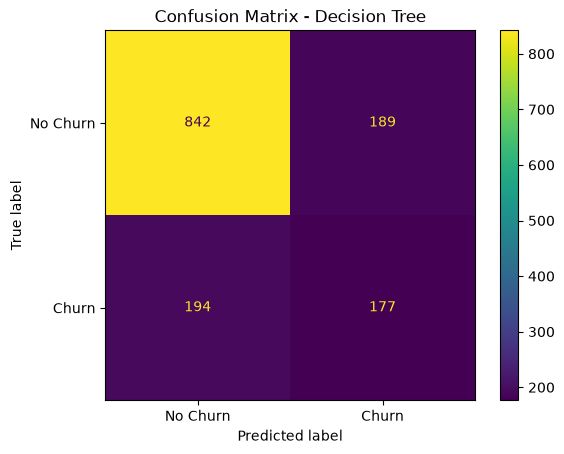

In [ ]:
# Task 11 — plot the confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Confusion Matrix - Decision Tree")
plt.show()

**Answer 11 (churners correctly caught vs. missed):**
The confusion matrix shows that 177 actual churners were correctly caught by the Decision Tree model. However, 194 actual churners were missed and incorrectly classified as No Churn. Therefore, the model correctly identified 177 churners and failed to identify 194 churners.

**Answer 12 (which metric(s) do you trust most, and why):**
Because the dataset has class imbalance, I would trust Recall and F1-score more than accuracy alone. Recall is particularly important because it measures how many of the actual churners are correctly identified by the model. Accuracy can be misleading with an imbalanced dataset because a model can obtain high accuracy by mostly predicting the majority class. F1-score is also useful because it balances precision and recall.

---

## 7. Overfitting Experiment

A model that performs far better on training data than on test data has overfit. Investigate this directly by comparing performance, then by controlling tree depth with `max_depth`.

*Concepts/functions you may find useful:* `accuracy_score(y_train, model.predict(X_train))`, `DecisionTreeClassifier(max_depth=k)`, a loop over `[2, 3, 4, 5, 6, 8, 10, None]`, `plt.plot(...)`

**Tasks**
13. Compare your baseline tree's accuracy on the training set vs. the test set. Is there a large gap? What does that suggest about the model?
14. Train several Decision Trees at different `max_depth` values (e.g. 2, 3, 4, 5, 6, 8, 10, and unrestricted). Record train accuracy and test accuracy for each in a results table.
15. Plot train accuracy and test accuracy against `max_depth` on the same chart. At roughly what depth does the model start to overfit? Explain how the chart shows this.

In [ ]:
# Task 13 — compare baseline train vs. test accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Baseline Decision Tree Accuracy")
print("--------------------------------")
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy :", test_accuracy)
print("Accuracy Gap     :", train_accuracy - test_accuracy)

Baseline Decision Tree Accuracy
--------------------------------
Training Accuracy: 0.9980385164051355
Testing Accuracy : 0.7268188302425107
Accuracy Gap     : 0.2712196861626248


**Answer 13:**
The baseline Decision Tree has a much higher accuracy on the training set than on the test set. This large gap suggests that the model is overfitting the training data. The tree has learned the training examples very closely, but its performance decreases on unseen test data. The depth of 20 also indicates that the baseline tree is relatively complex.

In [ ]:
# Task 14 — loop over max_depth values, record train/test accuracy

depths = [2, 3, 4, 5, 6, 8, 10, None]

train_accuracies = []
test_accuracies = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on training and testing data
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate accuracies
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    # Store results
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create results table
results_df = pd.DataFrame({
    "max_depth": depths,
    "Train Accuracy": train_accuracies,
    "Test Accuracy": test_accuracies
})

results_df

,max_depth,Train Accuracy,Test Accuracy
0,2.0,0.791548,0.786020
1,3.0,0.791548,0.786020
2,4.0,0.796184,0.783880
3,5.0,0.799929,0.782454
4,6.0,0.807240,0.789586
5,8.0,0.835235,0.793153
6,10.0,0.873217,0.775321
7,NaN,0.998039,0.726819


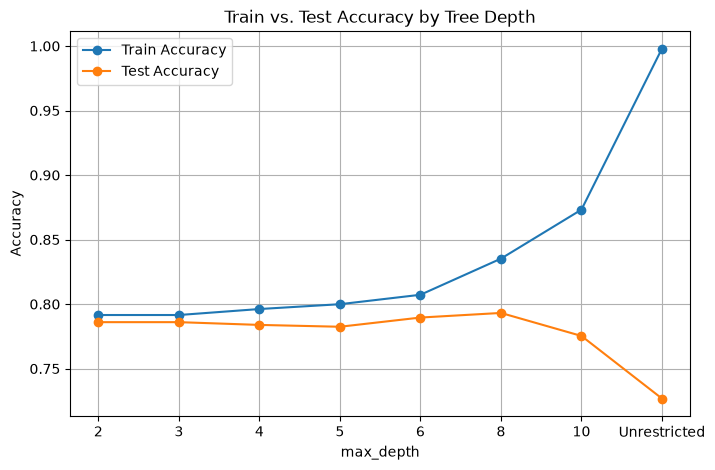

In [ ]:
# Task 15 — plot train vs. test accuracy against max_depth

# Convert None to a label for plotting
depth_labels = ["2", "3", "4", "5", "6", "8", "10", "Unrestricted"]

plt.figure(figsize=(8, 5))

plt.plot(depth_labels, train_accuracies, marker='o', label="Train Accuracy")
plt.plot(depth_labels, test_accuracies, marker='o', label="Test Accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Train vs. Test Accuracy by Tree Depth")
plt.legend()
plt.grid(True)
plt.show()

**Answer 15 (where overfitting starts, and why):**
The model starts to show signs of overfitting at approximately max_depth = 10. At this point, the training accuracy continues to increase, while the test accuracy decreases. This indicates that the deeper tree is fitting the training data too closely and is not generalizing as well to unseen data.

---

## 8. Model Comparison

Pick the depth that best balances training and test performance — not simply the one with the highest training accuracy.

**Tasks**
16. Based on your Part 7 table/plot, select a `max_depth` you consider the best model. Justify your choice in 2–3 sentences — it should not simply be the depth with the highest training accuracy.
17. Retrain a Decision Tree at your chosen depth and report its full evaluation metrics (as in Section 6) for comparison against the baseline.

**Answer 16 (chosen max_depth and justification):**
I selected max_depth = ___ because it provides a good balance between training and test performance. The I selected max_depth = 8 because it provides the best balance between training and test performance. At this depth, the test accuracy is the highest among the tested depths, while the training and test accuracies are still reasonably close. Deeper trees increase training accuracy but cause the test accuracy to decrease, indicating overfitting

In [ ]:
# Task 17 — retrain at chosen depth and report full evaluation metrics

# Train the chosen Decision Tree
chosen_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

chosen_model.fit(X_train, y_train)

# Predictions
chosen_train_pred = chosen_model.predict(X_train)
chosen_test_pred = chosen_model.predict(X_test)

# Evaluation metrics
chosen_accuracy = accuracy_score(y_test, chosen_test_pred)
chosen_precision = precision_score(
    y_test, chosen_test_pred, average='weighted'
)
chosen_recall = recall_score(
    y_test, chosen_test_pred, average='weighted'
)
chosen_f1 = f1_score(
    y_test, chosen_test_pred, average='weighted'
)

# Display metrics
print("Chosen Decision Tree (max_depth=8)")
print("----------------------------------")
print("Accuracy :", chosen_accuracy)
print("Precision:", chosen_precision)
print("Recall   :", chosen_recall)
print("F1-score :", chosen_f1)

Chosen Decision Tree (max_depth=8)
----------------------------------
Accuracy : 0.7931526390870185
Precision: 0.7839584487565865
Recall   : 0.7931526390870185
F1-score : 0.7867417915851431


**Task 17 — Baseline vs. Chosen Model**

| Metric        | Baseline (unrestricted) | Chosen Model (`max_depth = 8`) |
| ------------- | ----------------------: | -----------------------------: |
| **Accuracy**  |                0.726819 |                   **0.793153** |
| **Precision** |                0.725645 |                   **0.783958** |
| **Recall**    |                0.726819 |                   **0.793153** |
| **F1-score**  |                0.726223 |                   **0.786742** |


The chosen Decision Tree with max_depth = 8 performs better than the unrestricted baseline on all four evaluation metrics. Accuracy increased from 0.726819 to 0.793153, while precision, recall, and F1-score also improved. This indicates that limiting the tree depth reduced overfitting and improved the model's ability to generalize to the test data.

---

## 9. Feature Importance

Look inside your chosen model to see what it actually learned.

*Concepts/functions you may find useful:* `model.feature_importances_`, `pd.Series(importances, index=X.columns).sort_values()`, `plt.barh(...)`

**Task**
18. Extract and visualize `feature_importances_` for your chosen model. Which 3–5 features matter most?

In [ ]:
# Task 18 — extract and visualize feature importances
feature_importances = chosen_model.feature_importances_

# Create a DataFrame
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importances
})

# Sort from highest to lowest importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

# Display feature importances
importance_df

,Feature,Importance
1,tenure,0.321495
10,InternetService_Fiber optic,0.260086
3,TotalCharges,0.105608
2,MonthlyCharges,0.077483
25,Contract_Two year,0.043749
24,Contract_One year,0.026861
28,PaymentMethod_Electronic check,0.025357
12,OnlineSecurity_No internet service,0.017913
9,MultipleLines_Yes,0.014865
13,OnlineSecurity_Yes,0.013028


**Answer 18 (top 3–5 features):**
The five most important features are tenure (0.321495), InternetService_Fiber optic (0.260086), TotalCharges (0.105608), MonthlyCharges (0.077483), and Contract_Two year (0.043749). Among these, tenure has the highest importance, followed by InternetService_Fiber optic. These features contribute the most to the Decision Tree's predictions.
top 5
| Rank | Feature                         | Importance |
| ---: | ------------------------------- | ---------: |
|    1 | **tenure**                      |   0.321495 |
|    2 | **InternetService_Fiber optic** |   0.260086 |
|    3 | **TotalCharges**                |   0.105608 |
|    4 | **MonthlyCharges**              |   0.077483 |
|    5 | **Contract_Two year**           |   0.043749 |


---

## 10. Interpretation

Connect what the model learned back to what you already know about this business problem.

**Task**
19. In 2–3 sentences, connect the top features to what you already found in Lab 2's EDA — do they agree with the patterns you saw then?


**Answer 19:**
The top features identified by the Decision Tree generally agree with the patterns observed in Lab 2's EDA. In particular, tenure, MonthlyCharges, TotalCharges, Fiber optic internet service, and contract type were important patterns in the dataset, and the model also identified these features as strong predictors of customer churn. This shows that the Decision Tree is learning relationships that are consistent with the trends found during the exploratory analysis.

---

## 11. Conclusion

Step back from the code and summarize what you built and learned.

**Tasks**
20. Write a short conclusion (4–6 sentences): which model did you land on, how well does it perform, and what are its main limitations?
21. What would you try next if you had more time (e.g. a different algorithm, more feature engineering, handling class imbalance)? Describe it — do not implement it here.

**Answer 20 — Conclusion:**
In this lab, I built and evaluated a Decision Tree model for predicting customer churn. I selected a Decision Tree with max_depth = 8 because it provided a better balance between training and test performance than the unrestricted baseline. The chosen model achieved approximately 79.32% accuracy, with a precision of 78.40%, recall of 79.32%, and F1-score of 78.67% on the test set. The main limitation is that the dataset is imbalanced, and the model can still miss some actual churners. Another limitation is that a single Decision Tree may not generalize as well as ensemble methods on more complex patterns.

**Answer 21 — Next steps:**
If I had more time, I would try a Random Forest or another ensemble algorithm to see whether combining multiple trees improves generalization and reduces overfitting. I would also investigate different methods for handling the class imbalance, such as using class weights or resampling the minority class, so that actual churners are not missed as often. Finally, I would explore additional feature engineering and hyperparameter tuning to determine whether other combinations of customer and service features could improve the model's performance.

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Verification
- [ ] Section 3 — Feature/Target Preparation (with encoding justified)
- [ ] Section 4 — Train/Test Split
- [ ] Section 5 — Baseline Decision Tree
- [ ] Section 6 — Model Evaluation (accuracy, precision, recall, F1, confusion matrix — all with interpretation)
- [ ] Section 7 — Overfitting Experiment (results table + plot + explanation)
- [ ] Section 8 — Model Comparison (chosen depth justified, not just highest training accuracy)
- [ ] Section 9 — Feature Importance (extracted, visualized, and discussed)
- [ ] Section 10 — Interpretation (connected to Lab 2's EDA)
- [ ] Section 11 — Conclusion (limitations + next steps)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted